# California Housing — DNN 회귀 실습

# 1. 데이터 로딩 및 탐색

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = fetch_california_housing()
house_df = pd.DataFrame(data.data, columns=data.feature_names)
house_df['Price'] = data.target          # 단위: $100,000

print(house_df.shape)                    # (20640, 9)
print(house_df.describe())

(20640, 9)
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude         Price  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308  

In [2]:
house_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [3]:
house_df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'Price'],
      dtype='str')

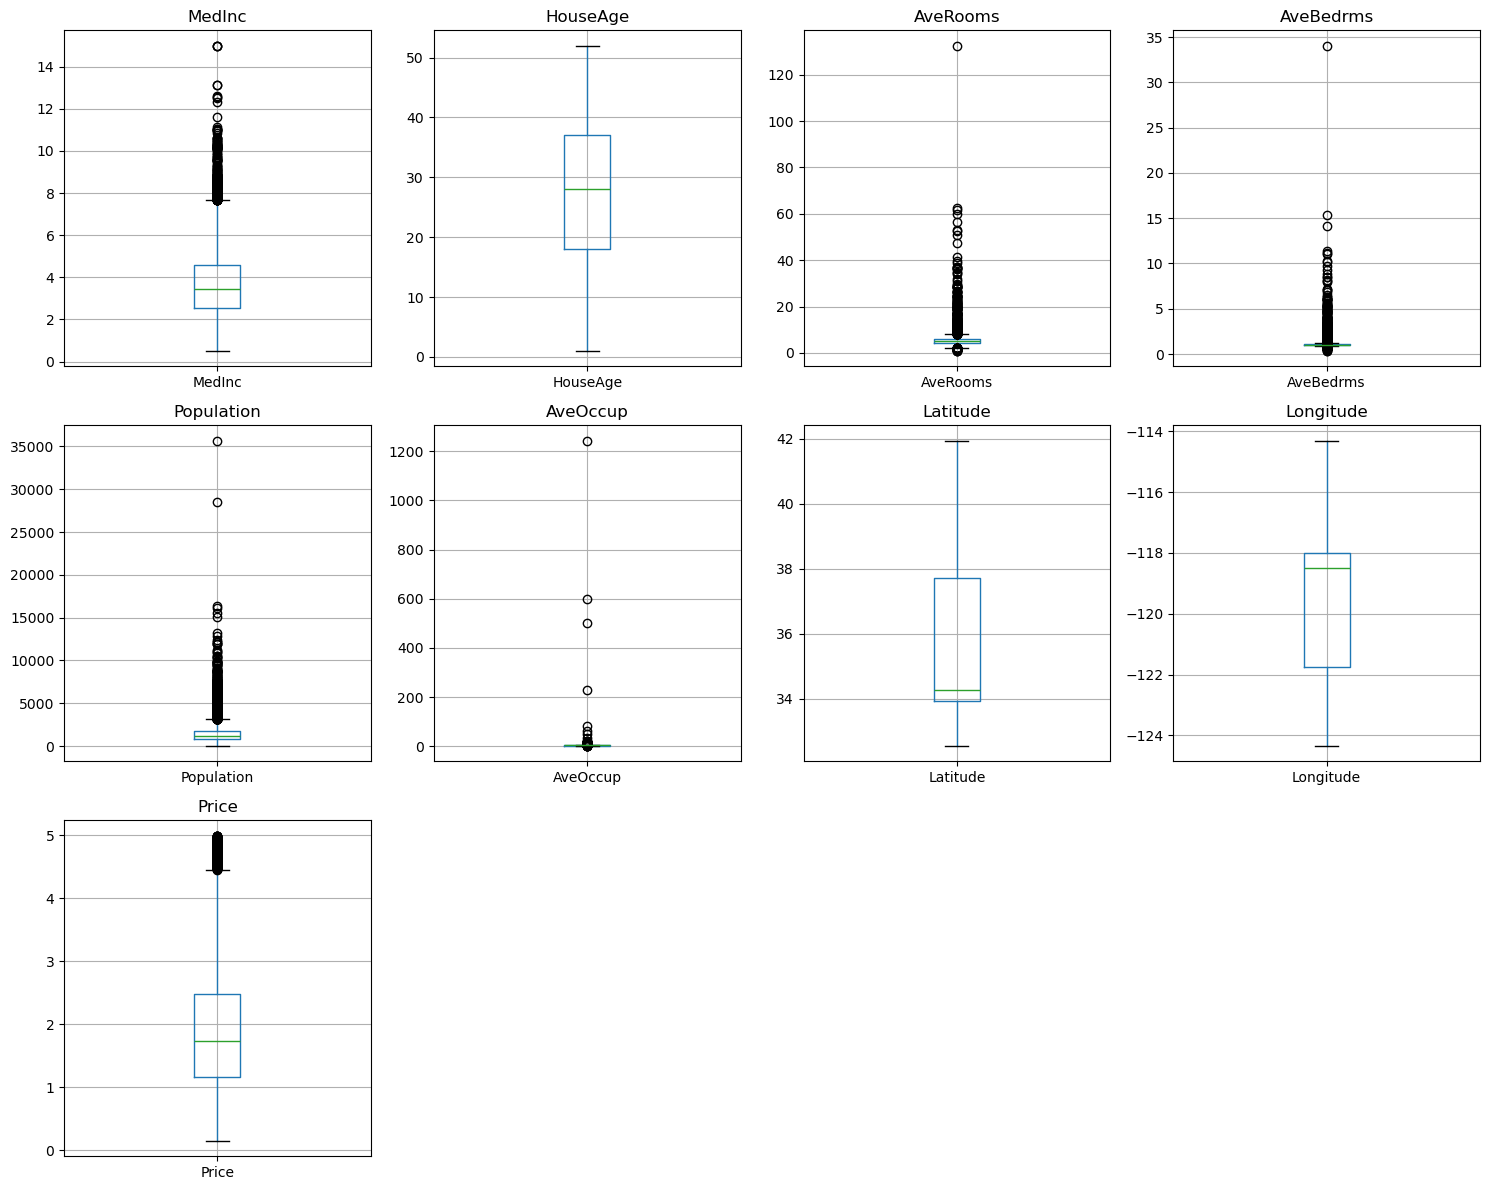

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 500,000 이상 데이터 삭제 : 이상 데이터
house_clipped_df = house_df[house_df['Price'] < 5.0]

# 수치형 컬럼만 선택
numeric_cols = house_df.select_dtypes(include=['float64', 'int64']).columns
box_count = len(numeric_cols)

boxes_per_row = 4
row_count = box_count // boxes_per_row +  ( 1 if box_count % boxes_per_row > 0 else 0)

# subplot 구조 설정 (예: 2행 3열)
fig, axes = plt.subplots(nrows=row_count, ncols=boxes_per_row, figsize=(15, 4*row_count))
axes = axes.flatten() # 1차원 배열로 변환

for i, col in enumerate(numeric_cols):
    house_clipped_df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)

# 빈 subplot 제거 (컬럼 수가 열*행보다 작을 경우)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

<Axes: >

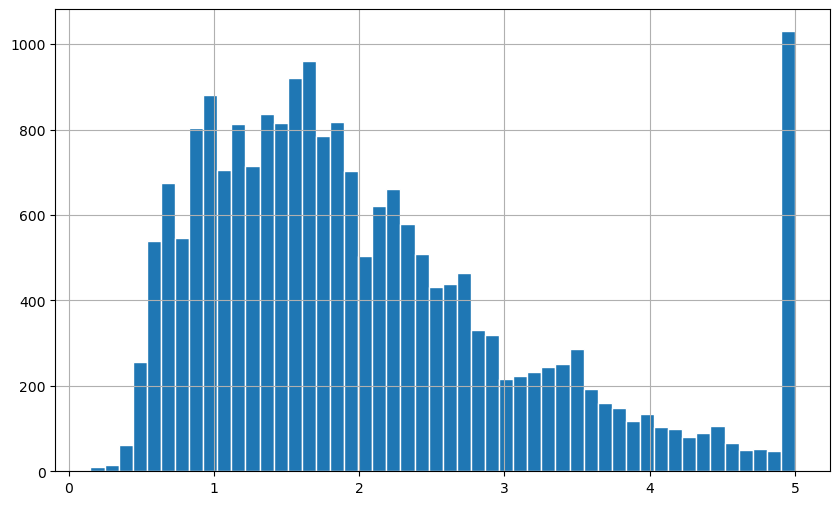

In [6]:
house_df['Price'].hist(bins=50, figsize=(10, 6), edgecolor='white')

In [9]:
len(house_df[house_df['Price'] > 5.0]), len(house_df[house_df['Price'] == 5.0]), float(house_df['Price'].max())

(965, 27, 5.00001)

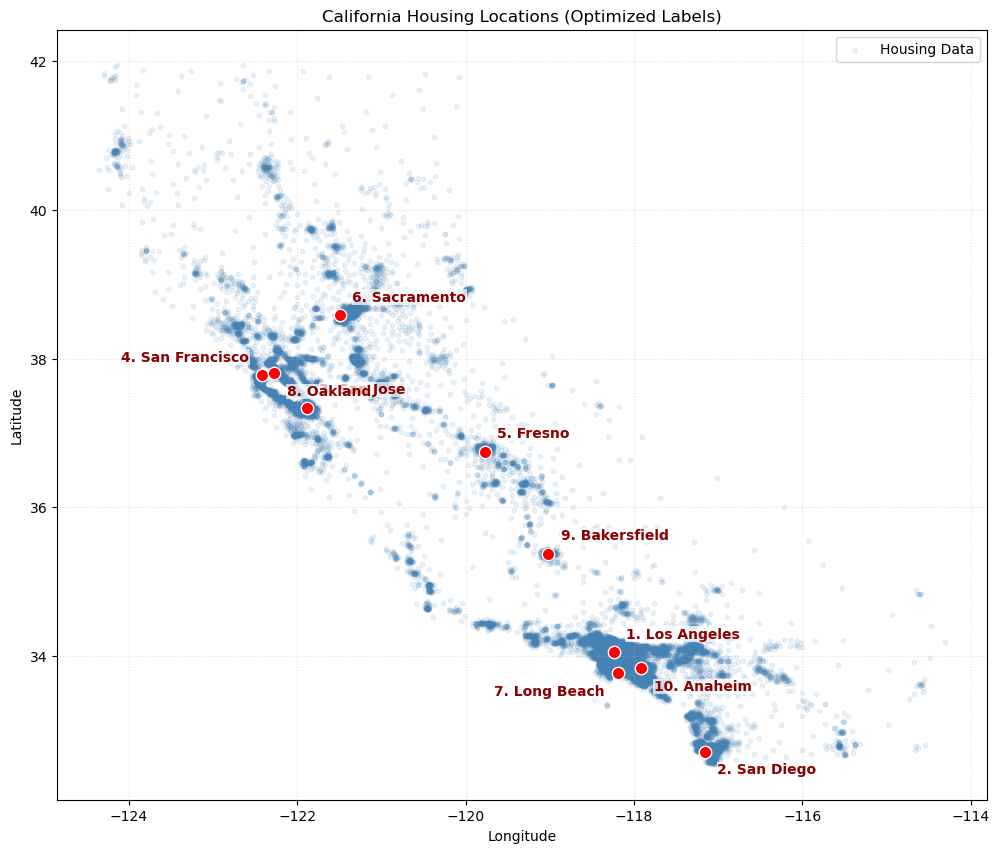

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
# 1. 배경 데이터 (청색)
plt.scatter(house_df['Longitude'], house_df['Latitude'], 
            alpha=0.1, color='steelblue', s=10, label='Housing Data')

# 2. 10대 도시 데이터 (가독성을 위한 오프셋 설정 포함)
# [경도, 위도, 수평정렬(ha), 수직정렬(va), 설명]
top_10_cities = {
    '1. Los Angeles': [-118.2437, 34.0522, 'left', 'bottom'],
    '2. San Diego': [-117.1611, 32.7157, 'left', 'top'],
    '3. San Jose': [-121.8863, 37.3382, 'left', 'bottom'],
    '4. San Francisco': [-122.4194, 37.7749, 'right', 'bottom'],
    '5. Fresno': [-119.7726, 36.7468, 'left', 'bottom'],
    '6. Sacramento': [-121.4944, 38.5816, 'left', 'bottom'],
    '7. Long Beach': [-118.1937, 33.7701, 'right', 'top'],
    '8. Oakland': [-122.2711, 37.8044, 'left', 'top'],
    '9. Bakersfield': [-119.0187, 35.3733, 'left', 'bottom'],
    '10. Anaheim': [-117.9145, 33.8366, 'left', 'top']
}

# 3. 도시 위치 표시 및 겹침 방지 레이블링
for city, info in top_10_cities.items():
    lon, lat, ha, va = info
    plt.scatter(lon, lat, color='red', s=80, edgecolors='white', zorder=10)
    
    # 텍스트 위치를 ha, va 설정에 따라 미세 조정
    dist = 0.15
    text_lon = lon - dist if ha == 'right' else lon + dist
    text_lat = lat - dist if va == 'top' else lat + dist

    plt.text(text_lon, text_lat, city, 
             fontsize=10, fontweight='bold', color='darkred',
             ha=ha, va=va, zorder=11,
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.5))

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('California Housing Locations (Optimized Labels)')
plt.grid(True, linestyle=':', alpha=0.4)
plt.legend(loc='upper right')
plt.show()



## 데이터의 통계적 특성을 이용한 전처리

In [19]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# 1. 로그 변환 (Skewed Features 처리)
# 데이터에 0이 있을 수 있으므로 log1p (log(1+x))를 사용합니다.
log_features = ['AveRooms', 'AveBedrms', 'Population', 'AveOccup']
for col in log_features:
    house_clipped_df[col] = np.log1p(house_clipped_df[col])

# 2. 데이터 분리
X = house_clipped_df.drop('Price', axis=1)
y = house_clipped_df['Price'].values

# for col in log_features:
#     house_df[col] = np.log1p(house_df[col])

# # 2. 데이터 분리
# X = house_df.drop('Price', axis=1)
# y = house_df['Price'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# 3. 스케일링 (RobustScaler 적용)
# 이상치(Outlier)의 영향력을 최소화하기 위해 평균 대신 중앙값을 사용합니다.
scaler = RobustScaler()

# Train 데이터로 학습하고 Train/Test 모두 변환
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 확인용 (DataFrame 형태가 필요할 때)
X_train_final = pd.DataFrame(X_train_scaled, columns=X.columns)


In [20]:
X_train_final, X_test_scaled.shape

(         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
 0     -0.409276 -0.052632 -1.243317  -0.758023    0.778545  1.010775   
 1      1.967834  1.263158  1.472735  -0.127251   -0.377078 -0.417866   
 2     -1.078886 -0.157895  0.197406   1.097204   -0.223980 -0.247422   
 3      0.969775 -0.736842  0.466322  -0.819282    0.115395  0.304935   
 4      0.538812  0.368421  0.486542  -0.528688   -0.652738 -0.010485   
 ...         ...       ...       ...        ...         ...       ...   
 13748 -0.167281  0.631579 -0.175786  -0.271079    0.094731 -0.397836   
 13749 -0.972201  0.473684 -0.587608  -0.239372    0.134767  1.093196   
 13750  0.874345 -1.210526  0.176726   0.395606    0.272176 -0.378420   
 13751 -0.199010 -0.157895 -0.168311   1.273809   -0.959170 -1.592857   
 13752 -0.674073 -1.157895 -0.307531  -0.770090    1.093216  1.813395   
 
        Latitude  Longitude  
 0     -0.055263   0.084881  
 1      0.931579  -0.989390  
 2      1.447368  -1.254642  
 3

##  모델 생성 및 옵션 설정

In [21]:
# import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

def build_model(input_shape):
    model = models.Sequential([
        # 입력층 및 첫 번째 은닉층
        layers.Dense(128, activation='relu', input_shape=(input_shape,)),
        layers.BatchNormalization(), # 학습 안정화 및 속도 향상
        layers.Dropout(0.2),         # 과적합 방지
        
        # 두 번째 은닉층
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.1),
        
        # 세 번째 은닉층
        layers.Dense(32, activation='relu'),
        
        # 출력층 (회귀 모델이므로 활성화 함수 없음 또는 Linear)
        layers.Dense(1)
    ])
    
    # 2. 컴파일 옵션 설정
    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.001), # 가장 범용적인 옵티마이저
        loss='mse',      # 회귀 문제의 표준 손실 함수 (Mean Squared Error)
        metrics=['mae']  # 실제 가격 차이를 직관적으로 확인하기 위함 (Mean Absolute Error)
    )
    
    return model

# 모델 생성
model = build_model(X_train_scaled.shape[1])
model.summary()


/home/ubuntu/miniforge3/envs/deepl/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 11,905 (46.50 KB)

 Non-trainable params: 384 (1.50 KB)

# 모델 학습 및 검증

In [22]:
from tensorflow.keras.callbacks import EarlyStopping

# 1. Early Stopping 설정 (검증 손실이 10번 이상 개선되지 않으면 중단)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 2. 학습 진행
history = model.fit(X_train_scaled, y_train, batch_size=32, epochs=100, verbose=1,  
                    # validation_split=0.2, : 테스트 용 데이터가 없을 시
                    validation_data=(X_test_scaled, y_test),
                    callbacks=[early_stopping]   # 최적화-3 : [Early Stopping 설정]
)

# 3. 평가 (회귀이므로 accuracy 대신 mae 사용)
loss, mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test MSE: {loss:.4f}, Test MAE: {mae:.4f}")

# 1. 테스트 데이터에 대한 예측값 생성
# pred = model.predict(X_test_scaled)

# 2. (선택사항) 결과 확인을 위해 1차원 배열로 평탄화
# 출력값이 [[0.12], [0.34]] 형태일 경우 [0.12, 0.34]로 변환해줍니다.
# pred = pred.flatten()



Epoch 1/100


I0000 00:00:1775033289.818440  110250 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_160097__.24


420/430 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0557 - mae: 0.7440

I0000 00:00:1775033291.936861  110251 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_160097__.24


430/430 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.6318 - mae: 0.5911 - val_loss: 0.4079 - val_mae: 0.4578
Epoch 2/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4085 - mae: 0.4772 - val_loss: 0.3013 - val_mae: 0.3956
Epoch 3/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3641 - mae: 0.4474 - val_loss: 0.2789 - val_mae: 0.3722
Epoch 4/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3410 - mae: 0.4313 - val_loss: 0.2944 - val_mae: 0.3772
Epoch 5/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3265 - mae: 0.4203 - val_loss: 0.2809 - val_mae: 0.3667
Epoch 6/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3103 - mae: 0.4081 - val_loss: 0.2685 - val_mae: 0.3686
Epoch 7/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3081 - mae: 0.4061 - val_loss: 0.2721 - val_mae: 0.3642
Epoch 8/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3022 - mae: 0.3996 - val_loss: 0.2797 - val_mae: 0.3619
Epoch 9/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - los

In [23]:
# 1. 테스트 데이터에 대한 예측값 생성
pred = model.predict(X_test_scaled)

# 2. (선택사항) 결과 확인을 위해 1차원 배열로 평탄화
# 출력값이 [[0.12], [0.34]] 형태일 경우 [0.12, 0.34]로 변환해줍니다.
# pred = pred.flatten()

185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


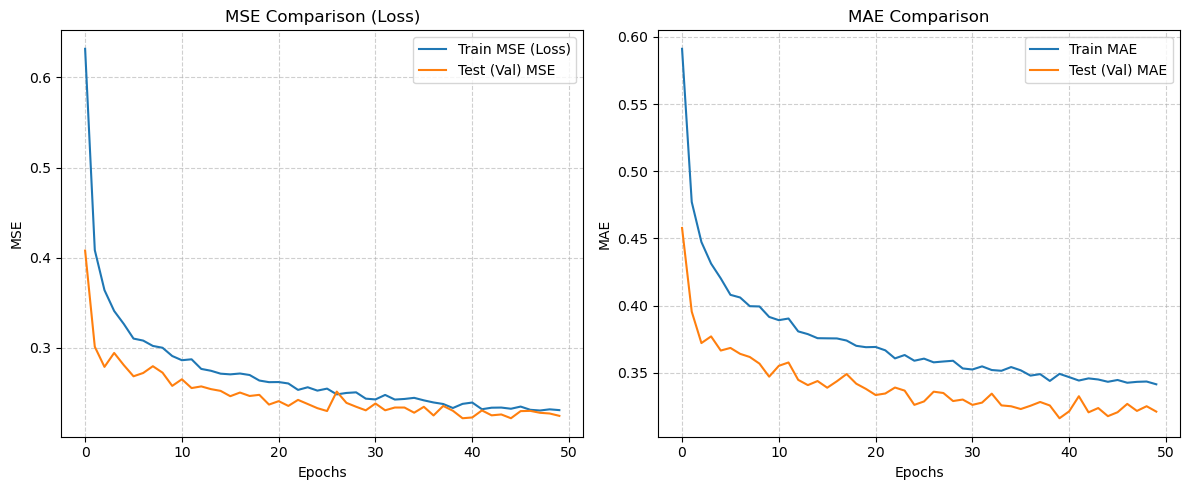

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# 1. Loss 비교 (MSE 기준)
# 회귀에서 기본 Loss는 주로 MSE(Mean Squared Error)를 사용합니다.
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train MSE (Loss)')
plt.plot(history.history['val_loss'], label='Test (Val) MSE')
plt.title('MSE Comparison (Loss)')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# 2. MAE 비교 (Mean Absolute Error)
# 실제 값과 얼마나 차이나는지 직관적인 오차를 보여줍니다.
# 주의: compile 시 metrics=['mae']를 추가했을 경우 'mae' 또는 'val_mae'로 기록됩니다.
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Test (Val) MAE')
plt.title('MAE Comparison')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


## 선 그래프: 실제값 vs 예측값 추이 비교

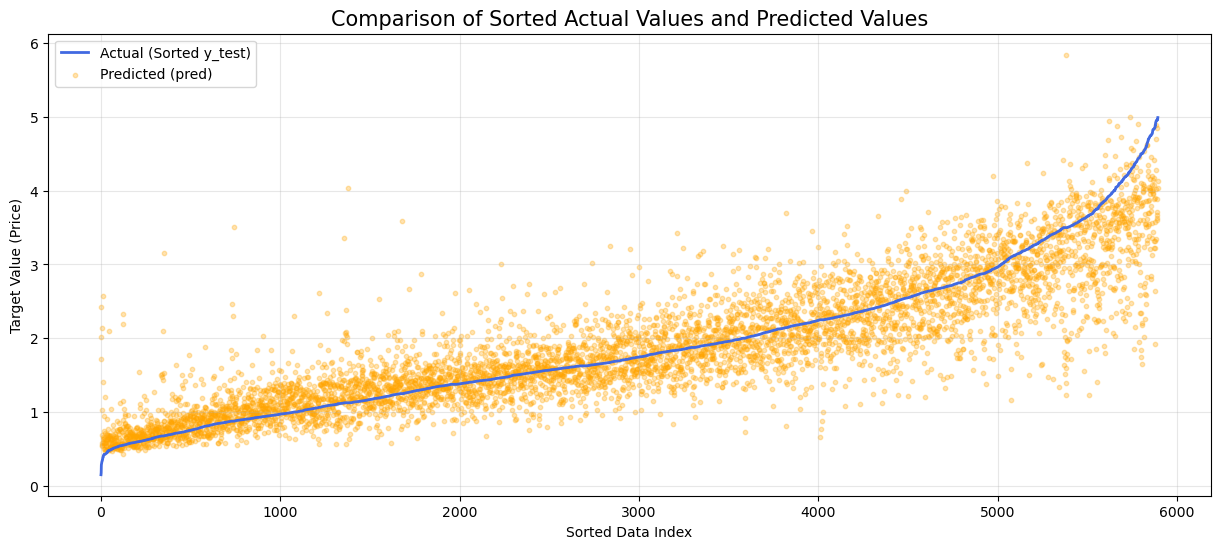

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 데이터를 넘파이 배열로 변환 및 평탄화
y_test_arr = np.array(y_test).flatten()
pred_arr = np.array(pred).flatten()

# 2. y_test 값을 기준으로 오름차순 정렬할 인덱스를 추출
sorted_indices = np.argsort(y_test_arr)

# 3. 추출한 인덱스 순서대로 y_test와 pred를 재정렬
y_test_sorted = y_test_arr[sorted_indices]
pred_sorted = pred_arr[sorted_indices]

plt.figure(figsize=(15, 6))

# 실제값 그래프 (정렬되어 있으므로 매끄러운 곡선 형태가 됩니다)
plt.plot(y_test_sorted, label='Actual (Sorted y_test)', color='royalblue', linewidth=2)

# 예측값 그래프 (실제값의 흐름을 얼마나 따라가는지 확인)
plt.scatter(range(len(pred_sorted)), pred_sorted, label='Predicted (pred)', 
            color='orange', alpha=0.3, s=10) # 점으로 표시하면 오차 분포가 더 잘 보입니다.

plt.title('Comparison of Sorted Actual Values and Predicted Values', fontsize=15)
plt.xlabel('Sorted Data Index')
plt.ylabel('Target Value (Price)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



## 산점도: 예측 정확도 분포 확인 (추천)

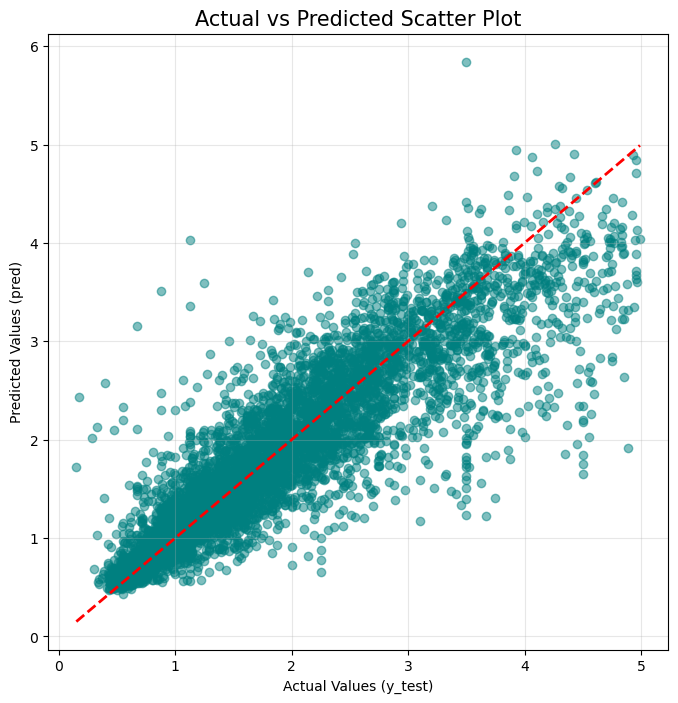

In [26]:
plt.figure(figsize=(8, 8))

# 산점도 그리기
plt.scatter(y_test, pred, alpha=0.5, color='teal')

# 완벽한 예측일 때의 대각선 (y=x 라인)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.title('Actual vs Predicted Scatter Plot', fontsize=15)
plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values (pred)')
plt.grid(True, alpha=0.3)
plt.show()


## 모델 성능 (500,000 이상 삭제 전후)
- 삭제후 : Test MSE: 0.2219, Test MAE: 0.3163
- 삭제전 : Test MSE: 0.2559, Test MAE: 0.3374 